### Problem Definition
- **What problem are we solving?** Predicting house prices based on property features.
- **Why is this problem important?** Real estate pricing is notoriously subjective. An ML model provides an objective baseline for valuations.
- **What type of ML problem is this?** Supervised Regression.

---

### Dataset
- **What information does this dataset contain?** Housing metrics (square footage, bedrooms, location).
- **What is the target?** House Price (Continuous variable).
- **What assumptions can we make before analysis?** We assume square footage and location have the strongest positive correlation with price.

In [32]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()

print(california.DESCR)
print(california.data.shape)
print(california.target)


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [33]:
import pandas as pd

pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', 9)
pd.set_option('display.width', None)

df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseValue'] = pd.Series(california.target)

print(df)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0    6.9841     1.0238       322.0    2.5556     37.88   
1      8.3014      21.0    6.2381     0.9719      2401.0    2.1098     37.86   
2      7.2574      52.0    8.2881     1.0734       496.0    2.8023     37.85   
3      5.6431      52.0    5.8174     1.0731       558.0    2.5479     37.85   
4      3.8462      52.0    6.2819     1.0811       565.0    2.1815     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0    5.0455     1.1333       845.0    2.5606     39.48   
20636  2.5568      18.0    6.1140     1.3158       356.0    3.1228     39.49   
20637  1.7000      17.0    5.2055     1.1201      1007.0    2.3256     39.43   
20638  1.8672      18.0    5.3295     1.1719       741.0    2.1232     39.43   
20639  2.3886      16.0    5.2547     1.1623      1387.0    2.6170     39.37   

       Longitude  MedHouseValue  
0    

### Exploratory Data Analysis
- **What should we learn from EDA?** Which features linearly correlate with the target.
- **Are there outliers?** Massive mansions will likely distort the standard distribution of prices.

In [34]:
import numpy as np

print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df[df.duplicated(keep=False)])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
MedInc           0
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseValue    0
dtype: int64
           MedInc    HouseAge    AveRooms   AveBedrms  Population    AveOccup  \
count  20640.0000  20640.0000  20640.0000  20640.0000  20640.0000  20640.0000   
mean       3.8707

                  MedInc  HouseAge  AveRooms  AveBedrms  ...  Longitude  \
MedInc            1.0000   -0.1190    0.3269    -0.0620  ...    -0.0152   
HouseAge         -0.1190    1.0000   -0.1533    -0.0777  ...    -0.1082   
AveRooms          0.3269   -0.1533    1.0000     0.8476  ...    -0.0275   
AveBedrms        -0.0620   -0.0777    0.8476     1.0000  ...     0.0133   
Population        0.0048   -0.2962   -0.0722    -0.0662  ...     0.0998   
AveOccup          0.0188    0.0132   -0.0049    -0.0062  ...     0.0025   
Latitude         -0.0798    0.0112    0.1064     0.0697  ...    -0.9247   
Longitude        -0.0152   -0.1082   -0.0275     0.0133  ...     1.0000   
MedHouseValue     0.6881    0.1056    0.1519    -0.0467  ...    -0.0460   
Bedroom_ratio    -0.6155    0.1364   -0.4187     0.0558  ...     0.0929   
rooms_per_person  0.2378   -0.1079    0.8873     0.8247  ...    -0.0744   

                  MedHouseValue  Bedroom_ratio  rooms_per_person  
MedInc                   0.6881 

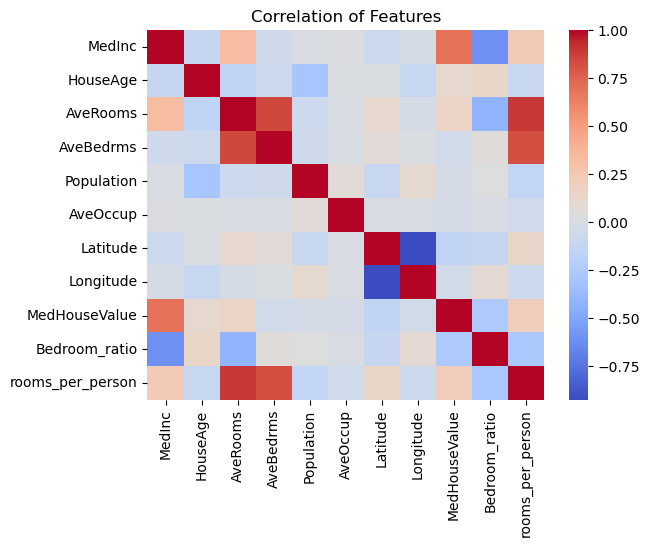

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

df["Bedroom_ratio"] = df['AveBedrms'] / df ['AveRooms']

df["rooms_per_person"] = df['AveRooms'] / df['AveOccup']

corr = df.corr()
print(corr)

sns.heatmap(corr, cmap='coolwarm', fmt='.2f')
plt.title('Correlation of Features')
plt.show()

### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

In [44]:
# for i in df.columns:
#     sns.boxplot(df[i])
#     plt.show()

skewed_features = ["AveRooms", "AveBedrms", "Population", "AveOccup", "Bedroom_ratio", "rooms_per_person"]


X = df.drop(columns='MedHouseValue')
y = df['MedHouseValue']

for col in skewed_features:
    X[col] = np.log1p(X[col])

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

### Data Preprocessing
- **Train-test split:** We divide our data to ensure we test the model on houses it has never seen before.

In [37]:
from sklearn.model_selection import train_test_split

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80, random_state=42)

In [38]:
from sklearn.preprocessing import StandardScaler

# Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Selection
- **Why choose this algorithm?** Linear Regression is the simplest baseline for regression.
- **What assumptions does it make?** It assumes a strictly linear relationship between the input features and the target price.
- **What are its weaknesses?** It cannot capture complex, non-linear real estate dynamics (e.g., a pool adding value in summer but not winter).

In [39]:
from sklearn.linear_model import LinearRegression

# Minimize the residual sum of squares between observed targets and the responses predicted by the linear approximation.
model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(model.coef_)
print(model.intercept_)

[ 0.75793135  0.14089235 -0.14797337 -0.1582429   0.0604009   0.13022088
 -0.91902144 -0.84863963  0.34908804  0.64320894]
2.07194693737888


### Evaluation
- **Why these metrics?** MSE (Mean Squared Error) heavily penalizes massive prediction errors, while R² tells us the percentage of price variance explained.
- **How should they be interpreted?** If R² is 0.80, the model explains 80% of why house prices change.

In [40]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

# Calculate the average absolute prediction error. Highly interpretable metric for business stakeholders.
mae = mean_absolute_error(y_test, y_pred)
# Heavily penalize massive prediction errors by squaring the residuals before averaging.
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

MAE: 0.4815
MSE: 0.4419
RMSE: 0.6648
R2: 0.6627


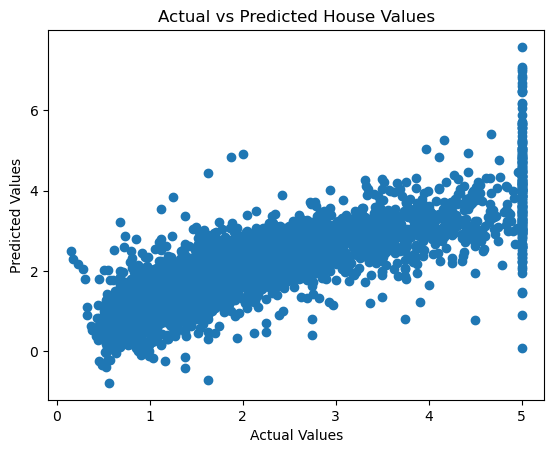

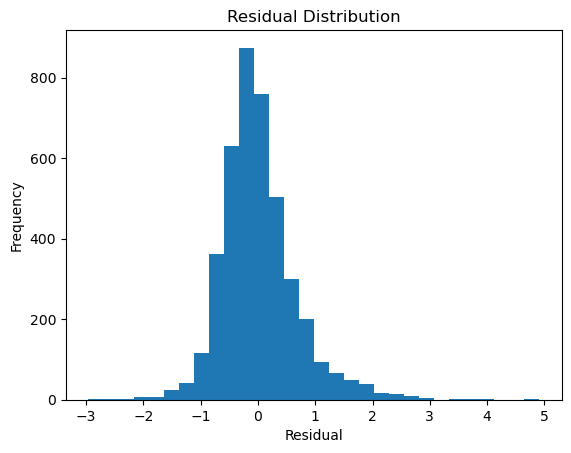

In [41]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Values")

plt.show()

residuals = y_test - y_pred

plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.show()

### Visualization Analysis: Scatter/Pair Plot
- **Marking Values:** Look for distinct clusters, straight lines, or chaotic clouds of points.
- **Correct Interpretation:** A clear diagonal trend indicates a linear relationship. Distinct, separated blobs indicate the data is highly clusterable or easily classified.
- **How to Interpret:** Each dot represents a single row of data plotted across two feature dimensions.
- **Common Mistakes:** Over-interpreting a 2D scatter plot when the model actually operates in high-dimensional space (PCA should be used to crush dimensions first).

In [42]:
from sklearn.model_selection import cross_val_score

# Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
scores = cross_val_score(model, X, y, cv=5)

print("CV R² Scores:", scores)
print("Mean CV R²:", scores.mean())
print("Std CV R²:", scores.std())

CV R² Scores: [0.61340322 0.59589066 0.6404169  0.59134739 0.69335466]
Mean CV R²: 0.626882566012337
Std CV R²: 0.0374343615291859


In [43]:
feature_importance = pd.Series(
    model.coef_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

MedInc              0.7579
rooms_per_person    0.6432
Bedroom_ratio       0.3491
HouseAge            0.1409
AveOccup            0.1302
Population          0.0604
AveRooms           -0.1480
AveBedrms          -0.1582
Longitude          -0.8486
Latitude           -0.9190
dtype: float64


### Conclusion
- **Biggest takeaway:** Linear Regression provides a fast, highly interpretable baseline, but struggles with outliers.
- **Possible improvements:** Applying Ridge or Lasso regularization to handle multi-collinearity.